# analysis.cooccurrence by library

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import igraph as ig
import networkx as nx
import matplotlib.pyplot as plt
import random
from daforfer import DaforferDB
from scipy import stats
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()
# db.tov()

┌──────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│         name         │                                                                                  description                                                                                   │
│       varchar        │                                                                                    varchar                                                                                     │
├──────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_sites              │ This table contains key information about each of the libraries, such as their site, habitat and host                                                                  

## Cooccurrences by library

In [35]:
cooccurrence_pairs = db.conn.sql('SELECT * FROM D_coocPairDetections').df()
cooccurrence_pairs

,library,pair
0,PV003bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
1,PV004bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
2,PV005bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
3,PV007bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
4,PV012bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
...,...,...
344,PV544,Agrobacterium tumefaciens-Beet western yellows...
345,PV544,Beet western yellows virus-Rhodococcoides fasc...
346,PV544,Beet western yellows virus-Sphingomonas sp. Le...
347,PV544,Rhodococcoides fascians-Rubus chlorotic mottle...


In [36]:
cooccurrence_pairs_counts_by_library = cooccurrence_pairs.value_counts(['library']).reset_index()
cooccurrence_pairs_counts_by_library

,library,count
0,PV215,39
1,PV212,34
2,PV217,20
3,PV218,17
4,PV224,16
...,...,...
69,PV132,1
70,PV157,1
71,PV169,1
72,PV004bgi,1


In [37]:
all_libraries = db.conn.sql("SELECT * FROM D_sites").df()[['library', 'site', 'habitat', 'host_taxon']].drop_duplicates("library")

cooccurrence_pairs_counts_by_library = pd.merge(all_libraries, cooccurrence_pairs_counts_by_library, on='library', how='left').fillna(0).sort_values(by='count', ascending=False)
cooccurrence_pairs_counts_by_library['pos'] = np.arange(len(cooccurrence_pairs_counts_by_library))
cooccurrence_pairs_counts_by_library

,library,site,habitat,host_taxon,count,pos
189,PV215,L3,Edge,Conyza bonariensis,39.0,0
186,PV212,L3,Edge,Amaranthus sp,34.0,1
191,PV217,L3,Edge,Datura stramonium,20.0,2
192,PV218,L3,Edge,Daucus sp,17.0,3
197,PV224,L3,Edge,Vicia sp,16.0,4
...,...,...,...,...,...,...
158,PV193,L2,Edge,Galium verum,0.0,318
159,PV194,L2,Edge,Papaver rhoeas,0.0,319
160,PV195,L2,Edge,Picris echioides,0.0,320
1,PV535,C1,Crop,Brassica oleracea,0.0,321


In [38]:
cooccurrence_pairs_counts_by_library[['count']].describe().round(4)

,count
count,323.0000
mean,1.0805
std,3.7993
min,0.0000
25%,0.0000
50%,0.0000
75%,0.0000
max,39.0000


In [39]:
cooccurrence_pairs_counts_by_library.query('count > 0')[['count']].describe().round(4)

,count
count,74.0000
mean,4.7162
std,6.8035
min,1.0000
25%,1.0000
50%,2.0000
75%,5.0000
max,39.0000


In [40]:
cooccurrence_pairs_counts_by_library.query('0 < count <= 1')[['count']].describe().round(4)

,count
count,33.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [41]:
cooccurrence_pairs_counts_by_library = cooccurrence_pairs_counts_by_library[['library', 'site', 'habitat', 'host_taxon', 'count']]
cooccurrence_pairs_counts_by_library['count'] = cooccurrence_pairs_counts_by_library['count'].astype(int)
cooccurrence_pairs_counts_by_library

/var/folders/xl/z7y434d524s8xpvqnb0gst580000gn/T/ipykernel_38054/4000376895.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cooccurrence_pairs_counts_by_library['count'] = cooccurrence_pairs_counts_by_library['count'].astype(int)


,library,site,habitat,host_taxon,count
189,PV215,L3,Edge,Conyza bonariensis,39
186,PV212,L3,Edge,Amaranthus sp,34
191,PV217,L3,Edge,Datura stramonium,20
192,PV218,L3,Edge,Daucus sp,17
197,PV224,L3,Edge,Vicia sp,16
...,...,...,...,...,...
158,PV193,L2,Edge,Galium verum,0
159,PV194,L2,Edge,Papaver rhoeas,0
160,PV195,L2,Edge,Picris echioides,0
1,PV535,C1,Crop,Brassica oleracea,0


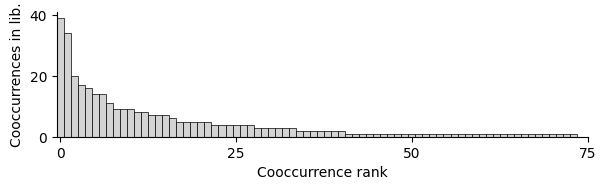

In [42]:
g = sns.catplot(
    x='library', y='count', 
    data=cooccurrence_pairs_counts_by_library.query('count > 0'), 
    kind='bar', dodge=False, height=2.0, aspect=3.0, edgecolor='black', linewidth=0.5, width=1.0,
    color='lightgray'
)
g.ax.set_xticks([0, 25, 50, 75])
g.set_xticklabels([0, 25, 50, 75])
g.set_xlabels("Cooccurrence rank")
g.set_ylabels("Cooccurrences in lib.")
g.savefig("figures/barplot.cooccurrences_by_library.svg")

## Cooccurrences by host

In [43]:
all_libraries

,library,site,habitat,host_taxon
0,PV534,C1,Crop,Diplotaxis erucoides
1,PV535,C1,Crop,Brassica oleracea
2,PV538,C1,Crop,Brassica oleracea
3,PV540,C1,Crop,Picris echioides
4,PV544,C1,Crop,Sisymbrium runcinatum
...,...,...,...,...
330,PV590,Z1,Crop,Zea mays
331,PV047,Z2,Crop,Zea mays
332,PV048,Z2,Crop,Desconocida 4
333,PV527,Z2,Crop,Convolvulus arvensis


In [44]:
host_habitat = all_libraries.groupby(['host_taxon'])['habitat'].apply(lambda x: ", ".join(list(set(x))))
host_habitat

host_taxon
Allium sativum                           Edge
Amaranthus sp                      Edge, Crop
Anacyclus clavatus      Edge, Crop, Wasteland
Anchusa undulata              Edge, Wasteland
Andryala arenaria                         Oak
                                ...          
Trifolium tomentosum                Wasteland
Verbascum sinuatum                  Wasteland
Vicia sp                      Edge, Wasteland
Xanthium strumarium                      Crop
Zea mays                                 Crop
Name: habitat, Length: 119, dtype: object

In [45]:
cooccurrence_by_host = pd.merge(cooccurrence_pairs, all_libraries, on='library').drop_duplicates(['host_taxon', 'pair'])[['host_taxon', 'pair']].value_counts('host_taxon').reset_index()
cooccurrence_by_host

,host_taxon,count
0,Conyza bonariensis,39
1,Amaranthus sp,37
2,Diplotaxis erucoides,22
3,Datura stramonium,21
4,Carduus bourgeanus,19
5,Daucus sp,19
6,Convolvulus arvensis,19
7,Vicia sp,16
8,Rubia peregrina,12
9,Cynodon dactylon,9


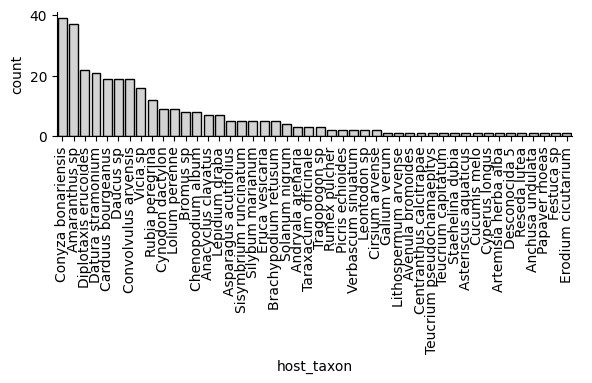

In [46]:
g = sns.catplot(cooccurrence_by_host, x='host_taxon', y='count', height=2.0, aspect=3.0, kind='bar', color='lightgray', edgecolor='black')
g.set_xticklabels(rotation=90)
g.savefig("figures/barplot.host_taxon_cooccurrences.svg")

## Cooccurrences by host / habitat

In [47]:
cooccurrence_by_host = pd.merge(host_habitat, cooccurrence_by_host, on='host_taxon', how='left').fillna(0).sort_values(by='count', ascending=False)
cooccurrence_by_host['count'] = cooccurrence_by_host['count'].astype(int)
cooccurrence_by_host

,host_taxon,habitat,count
29,Conyza bonariensis,Edge,39
1,Amaranthus sp,"Edge, Crop",37
41,Diplotaxis erucoides,"Edge, Wasteland, Crop",22
36,Datura stramonium,"Edge, Crop",21
37,Daucus sp,Edge,19
...,...,...,...
53,Geranium sp,"Edge, Wasteland, Oak",0
51,Fumaria parviflora,"Edge, Crop",0
50,Foeniculum vulgare,Wasteland,0
48,Eryngium campestre,"Wasteland, Oak",0


In [48]:
cooccurrence_by_host

,host_taxon,habitat,count
29,Conyza bonariensis,Edge,39
1,Amaranthus sp,"Edge, Crop",37
41,Diplotaxis erucoides,"Edge, Wasteland, Crop",22
36,Datura stramonium,"Edge, Crop",21
37,Daucus sp,Edge,19
...,...,...,...
53,Geranium sp,"Edge, Wasteland, Oak",0
51,Fumaria parviflora,"Edge, Crop",0
50,Foeniculum vulgare,Wasteland,0
48,Eryngium campestre,"Wasteland, Oak",0


In [49]:
cooccurrence_by_host_habitat = pd.merge(cooccurrence_pairs, all_libraries, on='library').drop_duplicates(['host_taxon', 'habitat', 'pair'])[['host_taxon', 'habitat', 'pair']].value_counts(['host_taxon', 'habitat']).reset_index().pivot(index='host_taxon', columns='habitat', values='count').fillna(0)
cooccurrence_by_host = pd.merge(cooccurrence_by_host, cooccurrence_by_host_habitat, on='host_taxon', how='left').fillna(0)
cooccurrence_by_host['Crop'] = cooccurrence_by_host['Crop'].astype(int)
cooccurrence_by_host['Edge'] = cooccurrence_by_host['Edge'].astype(int)
cooccurrence_by_host['Oak'] = cooccurrence_by_host['Oak'].astype(int)
cooccurrence_by_host['Wasteland'] = cooccurrence_by_host['Wasteland'].astype(int)
cooccurrence_by_host

,host_taxon,habitat,count,Crop,Edge,Oak,Wasteland
0,Conyza bonariensis,Edge,39,0,39,0,0
1,Amaranthus sp,"Edge, Crop",37,0,37,0,0
2,Diplotaxis erucoides,"Edge, Wasteland, Crop",22,8,16,0,0
3,Datura stramonium,"Edge, Crop",21,1,20,0,0
4,Daucus sp,Edge,19,0,19,0,0
...,...,...,...,...,...,...,...
114,Geranium sp,"Edge, Wasteland, Oak",0,0,0,0,0
115,Fumaria parviflora,"Edge, Crop",0,0,0,0,0
116,Foeniculum vulgare,Wasteland,0,0,0,0,0
117,Eryngium campestre,"Wasteland, Oak",0,0,0,0,0


## Correlation between cooccurrences per host and number of libraries per host

In [50]:
cooccurrence_by_host = pd.merge(
    cooccurrence_by_host, 
    all_libraries.value_counts('host_taxon').reset_index().rename(columns={'count': 'n_libraries'}),
    how='left', on='host_taxon'
)
cooccurrence_by_host

,host_taxon,habitat,count,Crop,Edge,Oak,Wasteland,n_libraries
0,Conyza bonariensis,Edge,39,0,39,0,0,2
1,Amaranthus sp,"Edge, Crop",37,0,37,0,0,5
2,Diplotaxis erucoides,"Edge, Wasteland, Crop",22,8,16,0,0,11
3,Datura stramonium,"Edge, Crop",21,1,20,0,0,3
4,Daucus sp,Edge,19,0,19,0,0,3
...,...,...,...,...,...,...,...,...
114,Geranium sp,"Edge, Wasteland, Oak",0,0,0,0,0,4
115,Fumaria parviflora,"Edge, Crop",0,0,0,0,0,4
116,Foeniculum vulgare,Wasteland,0,0,0,0,0,2
117,Eryngium campestre,"Wasteland, Oak",0,0,0,0,0,2


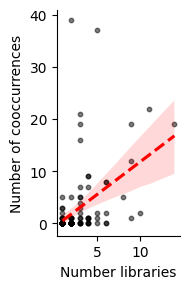

In [51]:
g = sns.lmplot(cooccurrence_by_host, x='n_libraries', y='count',
        height=3.0, aspect=2/3,
        scatter_kws={'alpha':0.5, 's':10, 'color': 'black'}, 
        line_kws={'color': 'red', 'linestyle':'--'}
)
g.set_xlabels("Number libraries")
g.set_ylabels("Number of cooccurrences")
g.savefig("figures/lmplot.libraries-cooccurrences.svg")

In [52]:
stats.linregress(cooccurrence_by_host['n_libraries'], cooccurrence_by_host['count'])

LinregressResult(slope=np.float64(1.251932696680309), intercept=np.float64(-0.7342374876280662), rvalue=np.float64(0.4417352790303839), pvalue=np.float64(4.929057825773654e-07), stderr=np.float64(0.23506546053584845), intercept_stderr=np.float64(0.8359563283147126))

In [ ]:
db.close()